# Package

In [64]:
# ============================================================
# 1) Core Python & Paths
# ============================================================
import sys
from pathlib import Path
from tempfile import TemporaryDirectory
from dateutil.relativedelta import relativedelta

# Project root (notebook dans /notebooks)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# 2) Data & Utils (Feast + custom utils)
# ============================================================
import pandas as pd
import numpy as np

from utils import load_wide_from_feast, build_unrate_exog_dataset
from experiment_utils import to_wide_from_oos, make_mae_dm_pivot

# ============================================================
# 3) Forecasting (MLForecast + Models)
# ============================================================
from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# ============================================================
# 4) Evaluation & Statistical Tests
# ============================================================
from scipy.stats import ttest_rel
from statsmodels.stats.contingency_tables import mcnemar

# ============================================================
# 5) Visualization
# ============================================================
from utilsforecast.plotting import plot_series
from IPython.display import IFrame, display

# ============================================================
# 6) Experiment Tracking (MLflow)
# ============================================================
import mlflow
from mlflow.tracking import MlflowClient

# Importation

In [65]:
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

START = "1960-01-01"
END   = "2025-08-01"

In [66]:
# 1) WIDE dataset (tu veux l'appeler df)
df = load_wide_from_feast(
    "stationary_value:value",
    series_ids,
    start=START,
    end=END
)

# 2) Convert WIDE -> LONG (obligatoire pour build_unrate_exog_dataset)
df_stationary = (
    df.reset_index()
      .melt(id_vars="date", var_name="series_id", value_name="value")
)

# 3) Build target + exog + MLForecast format
df_model, ts_lr, exog_cols = build_unrate_exog_dataset(df_stationary)

print("df (wide) shape:", df.shape)
print("df_stationary (long) shape:", df_stationary.shape)
print("df_model shape:", df_model.shape)
print("ts_lr shape:", ts_lr.shape)
print("Exog cols:", exog_cols)

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.
df (wide) shape: (788, 11)
df_stationary (long) shape: (8668, 3)
df_model shape: (788, 12)
ts_lr shape: (788, 13)
Exog cols: ['BUSLOANS', 'CPIAUCSL', 'DPCERA3M086SBEA', 'INDPRO', 'M2SL', 'OILPRICEX', 'RPI', 'SP500', 'TB3MS', 'USREC']


d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ML Experiment\utils.py:171: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


# Dictionnaire

In [67]:
MLF_MODELS = {
    "RIDGE_EXOG_ONLY": lambda freq, *, alpha=1.0: MLForecast(
        models={"RIDGE": Ridge(alpha=float(alpha), random_state=0)},
        freq=freq,
        lags=[],               # EXOG-ONLY
        date_features=[],
    )
}

# Backteting

## Helpers dates & slicing

In [68]:
def _ensure_ms(x):
    x = pd.Timestamp(x)
    return x.to_period("M").to_timestamp(how="start").normalize()

def _n_windows_monthly(ds_start, ds_end):
    return (ds_end.year - ds_start.year) * 12 + (ds_end.month - ds_start.month) + 1

def _slice_cv_block(ts, cutoff_start, n_windows, h):
    """
    Construit une slice de données suffisante pour cross_validation sur un bloc :
    on garde toutes les obs jusqu'à cutoff_end + h (pour générer les ds prédites)
    """
    cutoff_end = cutoff_start + relativedelta(months=n_windows - 1)
    ds_end = cutoff_end + relativedelta(months=h)
    return ts[ts["ds"] <= ds_end].copy(), cutoff_end, ds_end

## Tuning Ridge (alpha) sur train

In [69]:
def _tune_alpha_on_train(ts_train, *, alpha_grid, cv=5):
    """
    Tuning alpha sur les données train (sklearn CV) — EXOG-ONLY.
    On entraîne sur toutes les lignes de ts_train (pas de fuite car <= cutoff_start du bloc).
    """
    drop_cols = {"unique_id", "ds", "y"}
    x_cols = [c for c in ts_train.columns if c not in drop_cols]
    X = ts_train[x_cols].values
    y = ts_train["y"].values

    grid = GridSearchCV(
        Ridge(fit_intercept=True, random_state=0),
        {"alpha": alpha_grid},
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X, y)
    return float(grid.best_estimator_.alpha), float(-grid.best_score_)

## Backteting

In [70]:
def run_backtesting_h12_monthly_tune_every_36m(
    ts,
    *,
    freq,
    h=12,
    exp_start="1990-01-01",
    exp_end="2025-08-01",
    step_size=1,
    pi_windows=24,
    levels=[95],
    # tuning
    tune_every_months=36,
    alpha_mode="cv",                # "cv" ou float
    alpha_grid=np.logspace(-4, 4, 30),
    min_train_n=None,               # optionnel
):
    ts = ts.copy()

    # --- dates MS propres ---
    ts["ds"] = (
        pd.to_datetime(ts["ds"], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )
    if ts["ds"].isna().any():
        bad = ts[ts["ds"].isna()].head()
        raise ValueError(f"Dates 'ds' invalides après parsing. Exemples:\n{bad}")

    exp_start = _ensure_ms(exp_start)
    exp_end   = _ensure_ms(exp_end)

    cutoff_start_all = exp_start - relativedelta(months=h)
    cutoff_end_all   = exp_end   - relativedelta(months=h)
    total_partitions = _n_windows_monthly(cutoff_start_all, cutoff_end_all)

    # anti-fuite : on coupe à exp_end
    ts = ts[ts["ds"] <= exp_end].copy()

    # Conformal PI
    pi = PredictionIntervals(h=h, n_windows=pi_windows, method="conformal_distribution")

    # --- découpage en blocs de 36 mois (ou moins à la fin) ---
    blocks = []
    remaining = total_partitions
    cur_cutoff_start = cutoff_start_all

    while remaining > 0:
        n_win = min(tune_every_months, remaining)
        blocks.append((cur_cutoff_start, n_win))
        cur_cutoff_start = cur_cutoff_start + relativedelta(months=n_win)
        remaining -= n_win

    all_bkts = []
    alpha_history = []   # par bloc
    cv_mae_history = []  # par bloc

    for block_idx, (cutoff_start_blk, n_windows_blk) in enumerate(blocks, start=1):
        # --- data slice utile pour ce bloc ---
        ts_blk, cutoff_end_blk, ds_end_blk = _slice_cv_block(ts, cutoff_start_blk, n_windows_blk, h)

        # --- train pour tuner (<= cutoff_start_blk) ---
        ts_train_for_tune = ts[ts["ds"] <= cutoff_start_blk].copy()
        if min_train_n is not None and len(ts_train_for_tune) < int(min_train_n):
            continue

        # --- tuning alpha ---
        if alpha_mode == "cv":
            alpha_blk, cv_mae = _tune_alpha_on_train(ts_train_for_tune, alpha_grid=alpha_grid, cv=5)
        else:
            alpha_blk, cv_mae = float(alpha_mode), np.nan

        alpha_history.append(
            {"block": block_idx, "cutoff_start": cutoff_start_blk, "n_windows": n_windows_blk, "alpha": alpha_blk}
        )
        cv_mae_history.append(
            {"block": block_idx, "cutoff_start": cutoff_start_blk, "cv_mae": cv_mae}
        )

        # --- modèle Nixtla avec alpha figé sur le bloc ---
        mlf_blk = MLF_MODELS["RIDGE_EXOG_ONLY"](freq, alpha=alpha_blk)

        bkt_blk = mlf_blk.cross_validation(
            df=ts_blk,
            h=h,
            step_size=step_size,
            n_windows=n_windows_blk,
            prediction_intervals=pi,
            level=levels,
            fitted=True,
            static_features=[],
            dropna=True,
        )

        # tag bloc + alpha utilisé
        bkt_blk["tune_block"] = block_idx
        bkt_blk["alpha_used"] = alpha_blk
        all_bkts.append(bkt_blk)

    if not all_bkts:
        return pd.DataFrame(), {"error": "Aucun bloc backtest produit (min_train_n trop grand ?)"}

    bkt_df = pd.concat(all_bkts, ignore_index=True)

    # garder uniquement la plage d’expérience
    bkt_df = bkt_df[(bkt_df["ds"] >= exp_start) & (bkt_df["ds"] <= exp_end)].copy()
    bkt_df = bkt_df.sort_values(["unique_id", "ds", "cutoff"]).reset_index(drop=True)

    meta = {
        "h": h,
        "step_size": step_size,
        "exp_start": exp_start,
        "exp_end": exp_end,
        "cutoff_start": cutoff_start_all,
        "cutoff_end": cutoff_end_all,
        "partitions": total_partitions,
        "pi_windows": pi_windows,
        "tune_every_months": tune_every_months,
        "alpha_mode": alpha_mode,
        "alpha_grid": list(alpha_grid) if alpha_mode == "cv" else None,
        "alpha_history": alpha_history,
        "cv_mae_history": cv_mae_history,
    }

    return bkt_df, meta

### Execution

### Import + config

In [71]:
PROJECT_ROOT = Path.cwd().parent
print("PROJECT_ROOT =", PROJECT_ROOT.resolve())

FREQ = "MS"

H = 12
STEP_SIZE = 1
PI_WINDOWS = 3
LEVELS = [95]

EXP_START = "1990-01-01"
EXP_END   = "2025-08-01"

TUNE_EVERY_MONTHS = 36
ALPHA_MODE = "cv"  # ou float (ex: 1.0)
ALPHA_GRID = np.logspace(-4, 4, 30)

PROJECT_ROOT = D:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook


# Anti_fuite

In [72]:
ts_ridge = ts_lr.copy()

ts_ridge["ds"] = (
    pd.to_datetime(ts_ridge["ds"], errors="coerce")
      .dt.to_period("M")
      .dt.to_timestamp(how="start")
      .dt.normalize()
)

# anti-fuite
ts_ridge = ts_ridge[ts_ridge["ds"] <= pd.Timestamp(EXP_END)].copy()

print("ts_ridge shape:", ts_ridge.shape)
ts_ridge.head()

ts_ridge shape: (788, 13)


,unique_id,ds,y,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,USREC
0,UNRATE,1960-01-01,-0.8,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,0.0
1,UNRATE,1960-02-01,-1.1,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,0.0
2,UNRATE,1960-03-01,-0.2,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,0.0
3,UNRATE,1960-04-01,0.0,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0
4,UNRATE,1960-05-01,0.0,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,1.0


# Run Backteting

In [73]:
bkt_ridge, meta_ridge = run_backtesting_h12_monthly_tune_every_36m(
    ts=ts_ridge,
    freq=FREQ,
    h=H,
    exp_start=EXP_START,
    exp_end=EXP_END,
    step_size=STEP_SIZE,
    pi_windows=PI_WINDOWS,
    levels=LEVELS,
    tune_every_months=TUNE_EVERY_MONTHS,
    alpha_mode=ALPHA_MODE,
    alpha_grid=ALPHA_GRID,
    min_train_n=36,
)

bkt_ridge_final = (
    bkt_ridge.sort_values(["unique_id", "ds", "cutoff"])
             .groupby(["unique_id", "ds"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)


print("✅ meta_ridge keys:", list(meta_ridge.keys()))
print("bkt_ridge rows:", len(bkt_ridge))
print("bkt_ridge_final rows        :", len(bkt_ridge_final))
print("duplicates (unique_id, ds)  :", bkt_ridge_final.duplicated(["unique_id","ds"]).sum())
print("alphas used (unique)        :", sorted(bkt_ridge_final["alpha_used"].unique().tolist()))

bkt_ridge_final.head()

✅ meta_ridge keys: ['h', 'step_size', 'exp_start', 'exp_end', 'cutoff_start', 'cutoff_end', 'partitions', 'pi_windows', 'tune_every_months', 'alpha_mode', 'alpha_grid', 'alpha_history', 'cv_mae_history']
bkt_ridge rows: 5070
bkt_ridge_final rows        : 428
duplicates (unique_id, ds)  : 0
alphas used (unique)        : [0.03039195382313198, 0.05736152510448681, 0.38566204211634725, 1.3738237958832638, 2.592943797404667, 4.893900918477489, 9.236708571873866]


,unique_id,ds,cutoff,y,RIDGE,RIDGE-lo-95,RIDGE-hi-95,tune_block,alpha_used
0,UNRATE,1990-01-01,1989-12-01,0.0,-0.374110,-0.607142,-0.141079,1,0.385662
1,UNRATE,1990-02-01,1990-01-01,0.1,-0.415840,-1.277387,0.445707,1,0.385662
2,UNRATE,1990-03-01,1990-02-01,0.2,-0.424608,-1.467775,0.618558,1,0.385662
3,UNRATE,1990-04-01,1990-03-01,0.2,-0.334295,-1.268968,0.600377,1,0.385662
4,UNRATE,1990-05-01,1990-04-01,0.2,-0.069912,-0.794322,0.654498,1,0.385662


# Tableau

In [74]:
alpha_hist = pd.DataFrame(meta_ridge["alpha_history"]).copy()

alpha_hist["cutoff_start"] = pd.to_datetime(alpha_hist["cutoff_start"])
alpha_hist["cutoff_end"] = alpha_hist["cutoff_start"] + pd.offsets.MonthBegin(1) * (alpha_hist["n_windows"] - 1)

alpha_hist = alpha_hist[["block", "cutoff_start", "cutoff_end", "n_windows", "alpha"]]

C:\Users\Mita\AppData\Local\Temp\ipykernel_4876\870448483.py:4: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  alpha_hist["cutoff_end"] = alpha_hist["cutoff_start"] + pd.offsets.MonthBegin(1) * (alpha_hist["n_windows"] - 1)


C:\Users\Mita\AppData\Local\Temp\ipykernel_4876\594851353.py:7: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  alpha_hist["cutoff_end"] = alpha_hist["cutoff_start"] + pd.offsets.MonthBegin(1) * (alpha_hist["n_windows"] - 1)


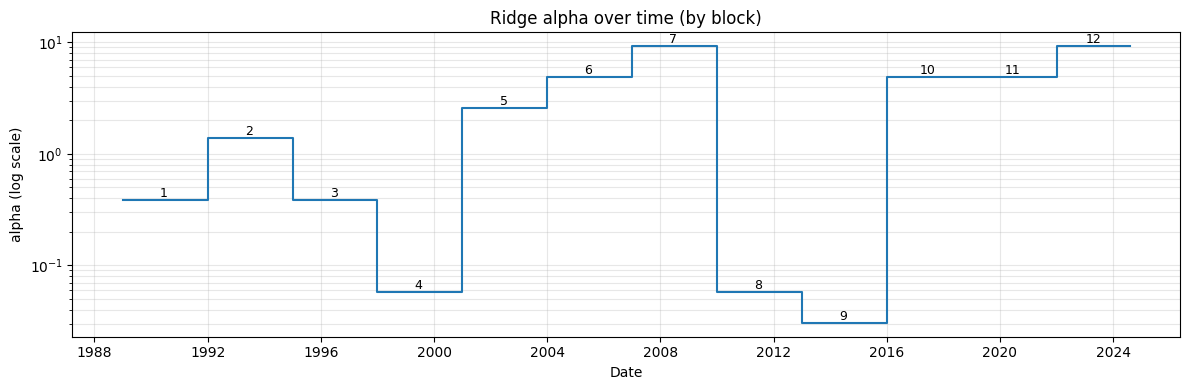

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# --- build alpha_hist exactly like you did
alpha_hist = pd.DataFrame(meta_ridge["alpha_history"]).copy()
alpha_hist["cutoff_start"] = pd.to_datetime(alpha_hist["cutoff_start"])
alpha_hist["cutoff_end"] = alpha_hist["cutoff_start"] + pd.offsets.MonthBegin(1) * (alpha_hist["n_windows"] - 1)
alpha_hist = alpha_hist[["block", "cutoff_start", "cutoff_end", "n_windows", "alpha"]].sort_values("cutoff_start")

# --- Step series: alpha constant over each block interval
x = [alpha_hist.loc[0, "cutoff_start"]]
y = [alpha_hist.loc[0, "alpha"]]
for _, r in alpha_hist.iterrows():
    x += [r["cutoff_start"], r["cutoff_end"]]
    y += [r["alpha"], r["alpha"]]

plt.figure(figsize=(12, 4))
plt.step(x, y, where="post")
plt.yscale("log")  # pratique car alpha varie beaucoup (0.03 -> 9.23)
plt.title("Ridge alpha over time (by block)")
plt.xlabel("Date")
plt.ylabel("alpha (log scale)")
plt.grid(True, which="both", alpha=0.3)

# --- Optional: show block id labels
for _, r in alpha_hist.iterrows():
    mid = r["cutoff_start"] + (r["cutoff_end"] - r["cutoff_start"]) / 2
    plt.text(mid, r["alpha"], str(int(r["block"])), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

L’évolution du paramètre alpha du modèle Ridge montre que le niveau de régularisation change selon les périodes économiques. 

Pendant les phases plus stables, comme la fin des années 1990 ou la période 2010–2015, les valeurs d’alpha restent faibles. le modèle utilise davantage les variables exogènes et capture plus facilement les relations entre les indicateurs macroéconomiques et le chômage.

À l’inverse, pendant les périodes d’instabilité économique ou de rupture, comme la crise de 2008 ou la période post-COVID, les valeurs d’alpha augmentent. Le modèle applique alors une régularisation plus forte pour rester stable. Celà évite le sur-apprentissage face à des relations plus incertaines.

Le tuning régulier du paramètre alpha permet donc d’adapter le modèle aux différents régimes économiques et d’améliorer la robustesse des prévisions.

# Paramètres RIDGE

In [76]:
import pandas as pd

# =========================================================
# Construire df_oos_ridge à partir de bkt_ridge_final
# =========================================================

# --- détecter la colonne de prediction (ex: "RIDGE") ---
pred_col = None
for c in bkt_ridge_final.columns:
    if c not in {"unique_id", "ds", "cutoff", "y"} and c.upper().startswith("RIDGE"):
        # évite RIDGE-lo-95 / RIDGE-hi-95
        if "-lo-" not in c and "-hi-" not in c:
            pred_col = c
            break

if pred_col is None:
    # fallback: la colonne "RIDGE" existe souvent
    if "RIDGE" in bkt_ridge_final.columns:
        pred_col = "RIDGE"
    else:
        raise ValueError(
            f"Impossible de détecter la colonne de prédiction RIDGE. Colonnes={list(bkt_ridge_final.columns)}"
        )

# --- colonnes PI (si présentes) ---
lo_col = f"{pred_col}-lo-95"
hi_col = f"{pred_col}-hi-95"

cols = ["ds", "y", pred_col]
if lo_col in bkt_ridge_final.columns and hi_col in bkt_ridge_final.columns:
    cols += [lo_col, hi_col]

df_oos_ridge = bkt_ridge_final[cols].copy()

# standardisation des noms
df_oos_ridge = df_oos_ridge.rename(columns={"ds": "date", "y": "y_true", pred_col: "y_hat"})
df_oos_ridge["date"] = pd.to_datetime(df_oos_ridge["date"], errors="coerce")
df_oos_ridge = df_oos_ridge.dropna(subset=["date"]).set_index("date").sort_index()

# rename PI to p05/p95 (si présentes)
if lo_col in df_oos_ridge.columns and hi_col in df_oos_ridge.columns:
    df_oos_ridge = df_oos_ridge.rename(columns={lo_col: "y_hat_p05", hi_col: "y_hat_p95"})

print(df_oos_ridge.head())
print("Columns:", df_oos_ridge.columns.tolist())


            y_true     y_hat  y_hat_p05  y_hat_p95
date                                              
1990-01-01     0.0 -0.374110  -0.607142  -0.141079
1990-02-01     0.1 -0.415840  -1.277387   0.445707
1990-03-01     0.2 -0.424608  -1.467775   0.618558
1990-04-01     0.2 -0.334295  -1.268968   0.600377
1990-05-01     0.2 -0.069912  -0.794322   0.654498
Columns: ['y_true', 'y_hat', 'y_hat_p05', 'y_hat_p95']


In [77]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =========================================================
# PARAMÈTRE
# =========================================================
alpha = 0.05  # 95% PI

# =========================================================
# Interval Score
# =========================================================
def interval_score(y, lo, hi, alpha=0.05):
    y = np.asarray(y, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)

    width = hi - lo
    below = (y < lo)
    above = (y > hi)

    penalty = (2 / alpha) * ((lo - y) * below + (y - hi) * above)
    return width + penalty

# =========================================================
# Périodes
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

# =========================================================
# Helper: standardiser les noms de colonnes RIDGE
# =========================================================
def standardize_ridge_oos(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # index datetime
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).set_index("date")
    elif "ds" in df.columns:
        df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
        df = df.dropna(subset=["ds"]).set_index("ds")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce")

    df = df[~df.index.isna()].sort_index()

    # y_true
    if "y_true" not in df.columns:
        for c in ["y", "UNRATE", "target"]:
            if c in df.columns:
                df["y_true"] = df[c]
                break

    # y_hat
    if "y_hat" not in df.columns:
        for c in ["RIDGE", "y_hat_ridge", "y_pred", "pred", "yhat"]:
            if c in df.columns:
                df["y_hat"] = df[c]
                break

    # PI columns
    if "y_hat_p05" not in df.columns:
        for c in ["RIDGE-lo-95", "lo_95", "p05", "y_p05"]:
            if c in df.columns:
                df["y_hat_p05"] = df[c]
                break

    if "y_hat_p95" not in df.columns:
        for c in ["RIDGE-hi-95", "hi_95", "p95", "y_p95"]:
            if c in df.columns:
                df["y_hat_p95"] = df[c]
                break

    return df

# =========================================================
# Calcul métriques RIDGE (mêmes clés que MLflow)
# =========================================================
df = standardize_ridge_oos(df_oos_ridge).copy().sort_index()

ridge_metrics = {}

for label, (start, end) in periods.items():

    sub = df.copy()

    if start is not None:
        sub = sub[sub.index >= pd.Timestamp(start)]
    if end is not None:
        sub = sub[sub.index <= pd.Timestamp(end)]

    if len(sub) == 0:
        continue

    # -------------------------------------------------
    # A) Point forecast
    # -------------------------------------------------
    sub_point = sub.dropna(subset=["y_true", "y_hat"])

    if len(sub_point) > 0:
        mae = mean_absolute_error(sub_point["y_true"], sub_point["y_hat"])
        ridge_metrics[f"mae_{label}"] = float(mae)
        ridge_metrics[f"n_obs_{label}"] = int(len(sub_point))
    else:
        ridge_metrics[f"mae_{label}"] = np.nan
        ridge_metrics[f"n_obs_{label}"] = 0

    # -------------------------------------------------
    # B) Prediction intervals
    # -------------------------------------------------
    sub_pi = sub.dropna(subset=["y_true", "y_hat_p05", "y_hat_p95"])

    if len(sub_pi) > 0:
        width = (sub_pi["y_hat_p95"] - sub_pi["y_hat_p05"]).astype(float)
        ridge_metrics[f"pi_avg_width_{label}"] = float(width.mean())
        ridge_metrics[f"pi_median_width_{label}"] = float(width.median())

        covered = (
            (sub_pi["y_true"] >= sub_pi["y_hat_p05"]) &
            (sub_pi["y_true"] <= sub_pi["y_hat_p95"])
        ).astype(int)

        ridge_metrics[f"pi_coverage_95_{label}"] = float(covered.mean())

        iscore = interval_score(
            sub_pi["y_true"].values,
            sub_pi["y_hat_p05"].values,
            sub_pi["y_hat_p95"].values,
            alpha=alpha
        )

        ridge_metrics[f"interval_score_mean_{label}"] = float(np.mean(iscore))
        ridge_metrics[f"interval_score_width_mean_{label}"] = float(np.mean(width.values))
        ridge_metrics[f"interval_score_penalty_mean_{label}"] = float(np.mean(iscore - width.values))

        ridge_metrics[f"n_pi_{label}"] = int(len(sub_pi))
    else:
        ridge_metrics[f"pi_avg_width_{label}"] = np.nan
        ridge_metrics[f"pi_median_width_{label}"] = np.nan
        ridge_metrics[f"pi_coverage_95_{label}"] = np.nan
        ridge_metrics[f"interval_score_mean_{label}"] = np.nan
        ridge_metrics[f"interval_score_width_mean_{label}"] = np.nan
        ridge_metrics[f"interval_score_penalty_mean_{label}"] = np.nan
        ridge_metrics[f"n_pi_{label}"] = 0

ridge_metrics["n_forecasts_total"] = int(len(df))

print(ridge_metrics)

# =========================================================
# Option: transformer en 1 ligne DataFrame pour concat
# (mêmes noms que ta table MLflow)
# =========================================================
metrics_df_ridge = pd.DataFrame([ridge_metrics], index=["RIDGE"])
display(metrics_df_ridge)


{'mae_ALL': 0.798518954434022, 'n_obs_ALL': 428, 'pi_avg_width_ALL': 2.7005333369068683, 'pi_median_width_ALL': 1.831737500615565, 'pi_coverage_95_ALL': 0.7757009345794392, 'interval_score_mean_ALL': 13.885820491311256, 'interval_score_width_mean_ALL': 2.7005333369068683, 'interval_score_penalty_mean_ALL': 11.185287154404387, 'n_pi_ALL': 428, 'mae_1990_1999': 0.4986827648030274, 'n_obs_1990_1999': 120, 'pi_avg_width_1990_1999': 1.619539115755706, 'pi_median_width_1990_1999': 1.4557764568140121, 'pi_coverage_95_1990_1999': 0.8083333333333333, 'interval_score_mean_1990_1999': 5.540160518239503, 'interval_score_width_mean_1990_1999': 1.619539115755706, 'interval_score_penalty_mean_1990_1999': 3.920621402483797, 'n_pi_1990_1999': 120, 'mae_2000_2008': 0.4459125924229421, 'n_obs_2000_2008': 108, 'pi_avg_width_2000_2008': 1.4291041841140293, 'pi_median_width_2000_2008': 0.9595772147304815, 'pi_coverage_95_2000_2008': 0.6759259259259259, 'interval_score_mean_2000_2008': 8.359496320239273, 'in

,mae_ALL,n_obs_ALL,pi_avg_width_ALL,pi_median_width_ALL,pi_coverage_95_ALL,interval_score_mean_ALL,interval_score_width_mean_ALL,interval_score_penalty_mean_ALL,n_pi_ALL,mae_1990_1999,...,mae_2020_fin,n_obs_2020_fin,pi_avg_width_2020_fin,pi_median_width_2020_fin,pi_coverage_95_2020_fin,interval_score_mean_2020_fin,interval_score_width_mean_2020_fin,interval_score_penalty_mean_2020_fin,n_pi_2020_fin,n_forecasts_total
RIDGE,0.798519,428,2.700533,1.831738,0.775701,13.88582,2.700533,11.185287,428,0.498683,...,1.886085,68,6.642428,5.46343,0.794118,40.305856,6.642428,33.663428,68,428


# Importer Artefact d'autres modèles depuis MLFLOW

In [78]:
import mlflow

# --------------------------------------------------
# 1) Connexion MLflow
# --------------------------------------------------
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# nom de ton experiment
experiment_name = "H2_testing"

exp = mlflow.get_experiment_by_name(experiment_name)
exp_id = exp.experiment_id

# --------------------------------------------------
# 2) Charger les runs (du plus récent au plus ancien)
# --------------------------------------------------
runs_df = mlflow.search_runs(
    experiment_ids=[exp_id],
    order_by=["start_time DESC"],
    max_results=200
)

# voir un aperçu
runs_df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.mae_2008_2019,metrics.mae_2000_2008,metrics.pi_avg_width_2008_2019,metrics.mae_2020_fin,...,tags.n_pi_ALL,tags.n_obs_2008_2019,tags.n_pi_1990_1999,tags.freq,tags.plot_logged,tags.n_obs_2000_2008,tags.n_obs_1990_1999,tags.model_name,tags.n_obs_ALL,tags.n_forecasts_total
0,4069f9c3f38d403b89a4e997f7e58127,1,FINISHED,mlflow-artifacts:/1/4069f9c3f38d403b89a4e997f7...,2026-02-20 15:03:48.953000+00:00,2026-02-20 15:03:49.179000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
1,8ef743cf9acf4df3a06639b6480f627e,1,FINISHED,mlflow-artifacts:/1/8ef743cf9acf4df3a06639b648...,2026-02-19 20:12:28.542000+00:00,2026-02-19 20:12:28.913000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
2,22159ff0aaeb4a539b4838d9af1a6e45,1,FINISHED,mlflow-artifacts:/1/22159ff0aaeb4a539b4838d9af...,2026-02-18 18:38:01.935000+00:00,2026-02-18 18:38:02.103000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
3,e8f8d9656af64df2af44f9780a85ac50,1,FINISHED,mlflow-artifacts:/1/e8f8d9656af64df2af44f9780a...,2026-02-18 18:36:10.357000+00:00,2026-02-18 18:36:10.602000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
4,b7433464bc40427d840a850a54d4d1dc,1,FINISHED,mlflow-artifacts:/1/b7433464bc40427d840a850a54...,2026-02-18 18:34:10.520000+00:00,2026-02-18 18:34:10.757000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None


# Vérification

In [79]:
import mlflow
print("tracking_uri =", mlflow.get_tracking_uri())

tracking_uri = http://127.0.0.1:5000


In [80]:
# --------------------------------------------------
# MLflow setup
# --------------------------------------------------
mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

# runs_df doit déjà exister (search_runs trié DESC)
candidate_run_ids = runs_df["run_id"].tolist()[:200]

# --------------------------------------------------
# helper : liste récursive des artifacts
# --------------------------------------------------
def list_artifacts_recursive(run_id: str, path: str = ""):
    out = []
    try:
        arts = client.list_artifacts(run_id, path)
    except Exception:
        return out

    for a in arts:
        if a.is_dir:
            out.extend(list_artifacts_recursive(run_id, a.path))
        else:
            out.append(a.path)
    return out

# --------------------------------------------------
# targets
# --------------------------------------------------
TARGETS = {
    "AR1": "evaluation/oos_predictions_ar1.csv",
    "ARp_CV": "evaluation/oos_predictions_arp_cv.csv",
    "LR_EXOG": "evaluation/oos_predictions_lr.csv",
}

found_runs = {k: None for k in TARGETS}

# --------------------------------------------------
# scan runs
# --------------------------------------------------
for rid in candidate_run_ids:

    paths = list_artifacts_recursive(rid)

    for model_name, target_file in TARGETS.items():
        if found_runs[model_name] is None and target_file in paths:
            found_runs[model_name] = rid

    # stop early if all found
    if all(v is not None for v in found_runs.values()):
        break

# --------------------------------------------------
# result
# --------------------------------------------------
print("=== RUN IDS FOUND ===")
for k, v in found_runs.items():
    print(f"{k}: {v}")

=== RUN IDS FOUND ===
AR1: 6478b7ba2b744d27b33ec53760c32962
ARp_CV: 441faaf7b03e4717b6d0f32a16b2a3a2
LR_EXOG: 97dff576636e422cbd0af50fe89ba674


In [81]:
from pathlib import Path

Path("evaluation").mkdir(parents=True, exist_ok=True)
print("Evaluation folder exists:", Path("evaluation").exists())

Evaluation folder exists: True


In [82]:
import mlflow
import shutil
from pathlib import Path
from mlflow.tracking import MlflowClient

# Tes run_ids
RUNS = {
    "LR_EXOG": "97dff576636e422cbd0af50fe89ba674",
    "ARp_CV":  "441faaf7b03e4717b6d0f32a16b2a3a2",
    "AR1":     "6478b7ba2b744d27b33ec53760c32962",
}

client = MlflowClient()
target_dir = Path("evaluation")
target_dir.mkdir(parents=True, exist_ok=True)

def has_eval_dir(run_id: str) -> bool:
    arts = client.list_artifacts(run_id, path="")
    return any(a.path == "evaluation" and a.is_dir for a in arts)

def copy_eval(run_id: str):
    src = mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="evaluation")
    shutil.copytree(src, target_dir, dirs_exist_ok=True)
    return src

picked = None
for name, rid in ["LR_EXOG", RUNS["LR_EXOG"]], ["ARp_CV", RUNS["ARp_CV"]], ["AR1", RUNS["AR1"]]:
    if has_eval_dir(rid):
        picked = (name, rid)
        break

if picked is None:
    print("❌ Aucun dossier 'evaluation/' trouvé à la racine des artefacts de ces runs.")
    # affiche ce qu'il y a à la racine pour debug
    for name, rid in RUNS.items():
        print(f"\n--- {name} ({rid}) root artifacts ---")
        for a in client.list_artifacts(rid, path=""):
            print(" ", a.path, "(dir)" if a.is_dir else "")
else:
    name, rid = picked
    src = copy_eval(rid)
    print(f"✅ Downloaded from {name} ({rid}) -> {src}")
    print("✅ Copied into:", target_dir.resolve())

    # vérif finale des 3 fichiers attendus
    for p in [
        "evaluation/dm_mae_pivot.csv",
        "evaluation/oos_predictions_lr.csv",
        "evaluation/plot_compare_AR1_ARp_CV_LR_EXOG.html",
    ]:
        print(p, "->", Path(p).exists())

✅ Downloaded from LR_EXOG (97dff576636e422cbd0af50fe89ba674) -> C:\Users\Mita\AppData\Local\Temp\tmp7o9dgai5\evaluation
✅ Copied into: D:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ML Experiment\evaluation
evaluation/dm_mae_pivot.csv -> True
evaluation/oos_predictions_lr.csv -> True
evaluation/plot_compare_AR1_ARp_CV_LR_EXOG.html -> True


In [83]:
dm = pd.read_csv("evaluation/dm_mae_pivot.csv")
oos_lr = pd.read_csv("evaluation/oos_predictions_lr.csv")

display(dm.head())
display(oos_lr.head())

,model,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
0,AR1,0.8788 (0.369),0.5078 (0.109),0.5356 (0.341),0.8686 (0.523),2.0848 (0.455)
1,ARp,0.8779 (0.447),0.4951,0.5287 (0.398),0.8442 (0.690),2.1595 (0.396)
2,LR,0.8120,0.5097 (0.825),0.4673,0.7976,1.8895


,date,y_true,y_hat,y_hat_p05,y_hat_p95
0,1990-01-01,0.0,-0.227449,-0.350798,-0.104100
1,1990-02-01,0.1,-0.373112,-1.363492,0.617268
2,1990-03-01,0.2,-0.458527,-1.787253,0.870200
3,1990-04-01,0.2,-0.435854,-1.898439,1.026731
4,1990-05-01,0.2,0.018847,-0.906300,0.943993


In [84]:
from pathlib import Path

files = sorted([p.name for p in Path("evaluation").glob("*")])
print("\n".join(files))

dm_mae_pivot.csv
oos_predictions_ar1.csv
oos_predictions_arp_cv.csv
oos_predictions_lr.csv
plot_compare_AR1_ARp_CV_LR_EXOG.html


In [85]:
import mlflow
import shutil
from pathlib import Path

RUNS = {
    "AR1": "6478b7ba2b744d27b33ec53760c32962",
    "ARp_CV": "441faaf7b03e4717b6d0f32a16b2a3a2",
}

target = Path("evaluation")
target.mkdir(exist_ok=True)

for name, rid in RUNS.items():
    src = mlflow.artifacts.download_artifacts(run_id=rid, artifact_path="evaluation")
    shutil.copytree(src, target, dirs_exist_ok=True)
    print(f"✅ Copied evaluation/ from {name} -> {src}")

print("\nNow local evaluation contains:")
for p in sorted(target.glob("*")):
    print(" -", p.name)


✅ Copied evaluation/ from AR1 -> C:\Users\Mita\AppData\Local\Temp\tmpnbvm_07n\evaluation


✅ Copied evaluation/ from ARp_CV -> C:\Users\Mita\AppData\Local\Temp\tmpkv50kvrm\evaluation

Now local evaluation contains:
 - dm_mae_pivot.csv
 - oos_predictions_ar1.csv
 - oos_predictions_arp_cv.csv
 - oos_predictions_lr.csv
 - plot_compare_AR1_ARp_CV_LR_EXOG.html


# Graphique démontrant l'évolution de RIDGE dan le temps

In [86]:
# 1) Load OOS from MLflow-exported CSVs (local now)
df_ar1 = pd.read_csv("evaluation/oos_predictions_ar1.csv")
df_arp = pd.read_csv("evaluation/oos_predictions_arp_cv.csv")
df_lr  = pd.read_csv("evaluation/oos_predictions_lr.csv")

# 2) Build wide (adds RIDGE from your bkt_ridge_final)
wide = to_wide_from_oos(
    df_ar1=df_ar1,
    df_arp=df_arp,
    df_lr=df_lr,
    bkt_ridge_final=bkt_ridge_final,  # <- ton DF ridge déjà calculé dans le notebook
)

# 3) Segments
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2008-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

# 4) MAE + DM pivot
table_pivot = make_mae_dm_pivot(
    wide=wide,
    segments=segments,
    methods=["AR1", "ARp", "LR", "RIDGE"],
    dm_lags=11,
    add_dm=True,
)

display(table_pivot)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,0.8788 (0.149),0.5078 (0.109),0.5356 (0.266),0.8686 (0.357),2.0848 (0.199)
ARp,0.8779 (0.230),0.4951,0.5287 (0.300),0.8442 (0.543),2.1595 (0.196)
LR,0.8120 (0.600),0.5097 (0.825),0.4673 (0.377),0.7976 (0.712),1.8895 (0.980)
RIDGE,0.7985,0.4987 (0.958),0.4459,0.7839,1.8861


# aUTRES Métriques 

In [87]:
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient

# --------------------------------------------------
# 1) Connexion MLflow
# --------------------------------------------------
mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

# --------------------------------------------------
# 2) Tes run_ids (comme tu as déjà)
# --------------------------------------------------
RUNS = {
    "AR1":     "6478b7ba2b744d27b33ec53760c32962",
    "ARp_CV":  "441faaf7b03e4717b6d0f32a16b2a3a2",
    "LR_EXOG": "97dff576636e422cbd0af50fe89ba674",
}

# --------------------------------------------------
# 3) Build metrics_df depuis MLflow
# --------------------------------------------------
rows = []
for model_name, run_id in RUNS.items():
    run = client.get_run(run_id)
    d = dict(run.data.metrics)          # toutes les métriques scalaires MLflow
    d["model"] = model_name
    d["run_id"] = run_id
    rows.append(d)

metrics_df = pd.DataFrame(rows).set_index("model")

# mapping propre (comme tes tableaux)
metrics_df = metrics_df.rename(index={"ARp_CV": "ARp", "LR_EXOG": "LR"})

# (optionnel) garder run_id à part si tu veux
run_ids_series = metrics_df["run_id"].copy()
metrics_df = metrics_df.drop(columns=["run_id"], errors="ignore")

print("metrics_df shape:", metrics_df.shape)
display(metrics_df.head())


metrics_df shape: (3, 55)


,mae_ALL,pi_avg_width_ALL,pi_median_width_ALL,pi_coverage_95_ALL,interval_score_mean_ALL,interval_score_width_mean_ALL,interval_score_penalty_mean_ALL,mae_1990_1999,pi_avg_width_1990_1999,pi_median_width_1990_1999,...,p_max_2000_2008,p_mode_2000_2008,p_mean_2008_2019,p_min_2008_2019,p_max_2008_2019,p_mode_2008_2019,p_mean_2020_fin,p_min_2020_fin,p_max_2020_fin,p_mode_2020_fin
model,,,,,,,,,,,,,,,,,,,,,
AR1,0.878795,3.212132,1.986367,0.735254,14.050498,3.212132,10.838365,0.507793,1.640354,1.549844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ARp,0.877921,3.279337,2.177537,0.757202,13.424005,3.279337,10.144668,0.495053,1.763992,1.721107,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
LR,0.811969,2.840552,1.944280,0.778037,13.821720,2.840552,10.981168,0.509729,1.724761,1.542454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
# ----------------------------
# 1) Coverage RIDGE par segment (à partir de df_oos_ridge)
# ----------------------------
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

def coverage_95(sub: pd.DataFrame) -> float:
    sub = sub.dropna(subset=["y_true", "y_hat_p05", "y_hat_p95"])
    if len(sub) == 0:
        return np.nan
    covered = (sub["y_true"] >= sub["y_hat_p05"]) & (sub["y_true"] <= sub["y_hat_p95"])
    return float(covered.mean())

df_r = df_oos_ridge.copy()
df_r.index = pd.to_datetime(df_r.index)

ridge_cov = {}
for label, (start, end) in periods.items():
    sub = df_r.copy()
    if start is not None:
        sub = sub[sub.index >= pd.Timestamp(start)]
    if end is not None:
        sub = sub[sub.index <= pd.Timestamp(end)]
    ridge_cov[f"pi_coverage_95_{label}"] = coverage_95(sub)

ridge_cov_df = pd.DataFrame([ridge_cov], index=["RIDGE"])


# ----------------------------
# 2) Merge avec metrics MLflow (AR1/ARp_CV/LR_EXOG)
# ----------------------------
m = metrics_df.copy().rename(index={"ARp_CV": "ARp", "LR_EXOG": "LR"})
metrics_all = pd.concat([m, ridge_cov_df], axis=0)

# ----------------------------
# 3) Tableau final Coverage (même format que MAE)
# ----------------------------
col_map = {
    "pi_coverage_95_ALL": "Ensemble",
    "pi_coverage_95_1990_1999": "1990-1999",
    "pi_coverage_95_2000_2008": "2000-2008",
    "pi_coverage_95_2008_2019": "2008-2019",
    "pi_coverage_95_2020_fin": "2020-fin",
}

ordered_keys = [k for k in col_map.keys() if k in metrics_all.columns]
coverage_table = metrics_all.loc[:, ordered_keys].rename(columns=col_map)

# ordre des lignes
coverage_table = coverage_table.reindex(["AR1", "ARp", "LR", "RIDGE"])

coverage_table = coverage_table.round(3)
coverage_table.columns.name = "period"
coverage_table.index.name = "model"

display(coverage_table)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,0.735,0.742,0.685,0.736,0.691
ARp,0.757,0.817,0.694,0.771,0.706
LR,0.778,0.817,0.685,0.792,0.779
RIDGE,0.776,0.808,0.676,0.764,0.794


In [89]:
# =========================================================
# 1) Charger OOS des modèles (aligné avec ton pipeline)
# =========================================================
df_ar1 = pd.read_csv("evaluation/oos_predictions_ar1.csv")
df_arp = pd.read_csv("evaluation/oos_predictions_arp_cv.csv")
df_lr  = pd.read_csv("evaluation/oos_predictions_lr.csv")

def prep_oos(df):
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.set_index("date").sort_index()
    return d

df_ar1 = prep_oos(df_ar1)
df_arp = prep_oos(df_arp)
df_lr  = prep_oos(df_lr)

df_ridge = df_oos_ridge.copy()
df_ridge.index = pd.to_datetime(df_ridge.index)
df_ridge = df_ridge.sort_index()

# =========================================================
# 2) Fonction coverage binaire (clé du test)
# =========================================================
def covered_series(df):
    df = df.dropna(subset=["y_true", "y_hat_p05", "y_hat_p95"])
    covered = (
        (df["y_true"] >= df["y_hat_p05"]) &
        (df["y_true"] <= df["y_hat_p95"])
    ).astype(int)
    return covered

# =========================================================
# 3) Test McNemar (paired coverage test)
# =========================================================
def coverage_mcnemar_test(df_ridge, df_other, start=None, end=None):
    
    d1 = df_ridge.copy()
    d2 = df_other.copy()
    
    if start is not None:
        d1 = d1[d1.index >= pd.Timestamp(start)]
        d2 = d2[d2.index >= pd.Timestamp(start)]
    if end is not None:
        d1 = d1[d1.index <= pd.Timestamp(end)]
        d2 = d2[d2.index <= pd.Timestamp(end)]
    
    # Alignement temporel (CRUCIAL)
    common_idx = d1.index.intersection(d2.index)
    d1 = d1.loc[common_idx]
    d2 = d2.loc[common_idx]
    
    c1 = covered_series(d1)
    c2 = covered_series(d2)
    
    common_idx = c1.index.intersection(c2.index)
    c1 = c1.loc[common_idx]
    c2 = c2.loc[common_idx]
    
    if len(c1) < 30:
        return "NaN", np.nan, 0
    
    # Table de contingence McNemar
    both_correct = np.sum((c1 == 1) & (c2 == 1))
    ridge_only   = np.sum((c1 == 1) & (c2 == 0))
    other_only   = np.sum((c1 == 0) & (c2 == 1))
    both_wrong   = np.sum((c1 == 0) & (c2 == 0))
    
    table = [[both_correct, ridge_only],
             [other_only, both_wrong]]
    
    result = mcnemar(table, exact=False, correction=True)
    
    cov_ridge = c1.mean()
    cov_other = c2.mean()
    diff = cov_ridge - cov_other
    
    return diff, result.pvalue, len(c1)

# =========================================================
# 4) Segments macro (comme ton pipeline)
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990-1999":  ("1990-01-01", "1999-12-31"),
    "2000-2008":  ("2000-01-01", "2008-12-31"),
    "2008-2019":  ("2008-01-01", "2019-12-31"),
    "2020-fin":   ("2020-01-01", None),
}

# =========================================================
# 5) Tableau de significativité Coverage (comme ton DM)
# =========================================================
comparisons = {
    "RIDGE vs AR1": df_ar1,
    "RIDGE vs ARp": df_arp,
    "RIDGE vs LR":  df_lr,
}

results = {}

for period_name, (start, end) in periods.items():
    row = {}
    
    for comp_name, df_other in comparisons.items():
        diff, p_val, n = coverage_mcnemar_test(
            df_ridge, df_other, start, end
        )
        
        if np.isnan(p_val):
            cell = "NaN"
        else:
            cell = f"Δcov={diff:.3f} (p={p_val:.3f})"
        
        row[comp_name] = cell
    
    results[period_name] = row

coverage_significance_pivot = pd.DataFrame(results).T
coverage_significance_pivot.index.name = "period"

display(coverage_significance_pivot)


,RIDGE vs AR1,RIDGE vs ARp,RIDGE vs LR
period,,,
ALL,Δcov=0.040 (p=0.051),Δcov=0.002 (p=1.000),Δcov=-0.002 (p=1.000)
1990-1999,Δcov=0.067 (p=0.170),Δcov=-0.008 (p=1.000),Δcov=-0.008 (p=1.000)
2000-2008,Δcov=-0.009 (p=1.000),Δcov=-0.019 (p=0.803),Δcov=-0.009 (p=1.000)
2008-2019,Δcov=0.028 (p=0.522),Δcov=-0.007 (p=1.000),Δcov=-0.028 (p=0.386)
2020-fin,Δcov=0.103 (p=0.023),Δcov=0.088 (p=0.041),Δcov=0.015 (p=1.000)


In [90]:
# =========================================================
# 1) Calcul width RIDGE par segment (comme MLflow)
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

df_r = df_oos_ridge.copy()
df_r.index = pd.to_datetime(df_r.index, errors="coerce")
df_r = df_r.sort_index()

required_cols = {"y_hat_p05", "y_hat_p95"}
missing = required_cols - set(df_r.columns)
if missing:
    raise ValueError(f"df_oos_ridge manque les colonnes d'intervalles: {missing}")

ridge_width = {}

for label, (start, end) in periods.items():
    sub = df_r.copy()

    if start is not None:
        sub = sub[sub.index >= pd.Timestamp(start)]
    if end is not None:
        sub = sub[sub.index <= pd.Timestamp(end)]

    sub = sub.dropna(subset=["y_hat_p05", "y_hat_p95"])

    if len(sub) == 0:
        ridge_width[f"pi_avg_width_{label}"] = np.nan
        ridge_width[f"pi_median_width_{label}"] = np.nan
        continue

    width = (sub["y_hat_p95"] - sub["y_hat_p05"]).astype(float)

    ridge_width[f"pi_avg_width_{label}"] = float(width.mean())
    ridge_width[f"pi_median_width_{label}"] = float(width.median())

ridge_width_df = pd.DataFrame([ridge_width], index=["RIDGE"])

# =========================================================
# 2) Merge avec metrics MLflow (AR1 / ARp / LR)
# =========================================================
m = metrics_df.copy().rename(index={"ARp_CV": "ARp", "LR_EXOG": "LR"})
all_metrics = pd.concat([m, ridge_width_df], axis=0)

# =========================================================
# 3) Tableau final WIDTH (même format que MAE)
# =========================================================
col_map = {
    "pi_avg_width_ALL": "Ensemble",
    "pi_avg_width_1990_1999": "1990-1999",
    "pi_avg_width_2000_2008": "2000-2008",
    "pi_avg_width_2008_2019": "2008-2019",
    "pi_avg_width_2020_fin": "2020-fin",
}

ordered_keys = [k for k in col_map.keys() if k in all_metrics.columns]
if not ordered_keys:
    raise ValueError("Aucune colonne pi_avg_width_* trouvée dans metrics.")

width_table = (
    all_metrics.loc[:, ordered_keys]
    .rename(columns=col_map)
    .reindex(["AR1", "ARp", "LR", "RIDGE"])
    .round(3)
)

width_table.columns.name = "period"
width_table.index.name = "model"

display(width_table)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,3.212,1.640,1.511,2.770,8.661
ARp,3.279,1.764,1.570,2.904,9.136
LR,2.841,1.725,1.588,2.617,6.950
RIDGE,2.701,1.620,1.429,2.528,6.642


In [91]:


# =========================================================
# 1) Préparer les OOS des autres modèles (MLflow CSV)
# =========================================================
df_ar1 = pd.read_csv("evaluation/oos_predictions_ar1.csv")
df_arp = pd.read_csv("evaluation/oos_predictions_arp_cv.csv")
df_lr  = pd.read_csv("evaluation/oos_predictions_lr.csv")

def prep_oos(df):
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.set_index("date").sort_index()
    return d

df_ar1 = prep_oos(df_ar1)
df_arp = prep_oos(df_arp)
df_lr  = prep_oos(df_lr)

df_ridge = df_oos_ridge.copy()
df_ridge.index = pd.to_datetime(df_ridge.index)
df_ridge = df_ridge.sort_index()

# =========================================================
# 2) Fonction width
# =========================================================
def compute_width(df):
    return (df["y_hat_p95"] - df["y_hat_p05"]).astype(float)

# =========================================================
# 3) Test pairwise (RIDGE vs autre modèle)
# =========================================================
def paired_width_test(df_ridge, df_other, start=None, end=None):
    
    d1 = df_ridge.copy()
    d2 = df_other.copy()
    
    if start is not None:
        d1 = d1[d1.index >= pd.Timestamp(start)]
        d2 = d2[d2.index >= pd.Timestamp(start)]
    if end is not None:
        d1 = d1[d1.index <= pd.Timestamp(end)]
        d2 = d2[d2.index <= pd.Timestamp(end)]
    
    # Alignement temporel (CRUCIAL en OOS)
    common_idx = d1.index.intersection(d2.index)
    d1 = d1.loc[common_idx]
    d2 = d2.loc[common_idx]
    
    d1 = d1.dropna(subset=["y_hat_p05", "y_hat_p95"])
    d2 = d2.dropna(subset=["y_hat_p05", "y_hat_p95"])
    
    common_idx = d1.index.intersection(d2.index)
    
    if len(common_idx) < 30:
        return np.nan, np.nan, 0
    
    w1 = compute_width(d1.loc[common_idx])
    w2 = compute_width(d2.loc[common_idx])
    
    # Paired t-test (le bon choix en forecasting)
    t_stat, p_val = ttest_rel(w1, w2)
    
    mean_diff = (w1 - w2).mean()  # < 0 => RIDGE plus étroit
    
    return t_stat, p_val, mean_diff, len(common_idx)

# =========================================================
# 4) Segments macro (comme ton pipeline)
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990-1999":  ("1990-01-01", "1999-12-31"),
    "2000-2008":  ("2000-01-01", "2008-12-31"),
    "2008-2019":  ("2008-01-01", "2019-12-31"),
    "2020-fin":   ("2020-01-01", None),
}

# =========================================================
# 5) Tableau de significativité (comme ton DM table)
# =========================================================
comparisons = {
    "RIDGE vs AR1": df_ar1,
    "RIDGE vs ARp": df_arp,
    "RIDGE vs LR":  df_lr,
}

results = {}

for period_name, (start, end) in periods.items():
    row = {}
    
    for comp_name, df_other in comparisons.items():
        t_stat, p_val, mean_diff, n = paired_width_test(
            df_ridge, df_other, start, end
        )
        
        if np.isnan(p_val):
            cell = "NaN"
        else:
            # Format comme ton tableau DM
            cell = f"Δ={mean_diff:.3f} (p={p_val:.3f})"
        
        row[comp_name] = cell
    
    results[period_name] = row

width_significance_pivot = pd.DataFrame(results).T
width_significance_pivot.index.name = "period"

display(width_significance_pivot)

,RIDGE vs AR1,RIDGE vs ARp,RIDGE vs LR
period,,,
ALL,Δ=-0.426 (p=0.000),Δ=-0.593 (p=0.000),Δ=-0.140 (p=0.007)
1990-1999,Δ=-0.021 (p=0.731),Δ=-0.144 (p=0.012),Δ=-0.105 (p=0.000)
2000-2008,Δ=-0.082 (p=0.285),Δ=-0.141 (p=0.044),Δ=-0.158 (p=0.000)
2008-2019,Δ=-0.241 (p=0.030),Δ=-0.376 (p=0.000),Δ=-0.088 (p=0.008)
2020-fin,Δ=-2.018 (p=0.000),Δ=-2.493 (p=0.000),Δ=-0.307 (p=0.331)


In [95]:
df_oos_ridge

,y_true,y_hat,y_hat_p05,y_hat_p95
date,,,,
1990-01-01,0.0,-0.374110,-0.607142,-0.141079
1990-02-01,0.1,-0.415840,-1.277387,0.445707
1990-03-01,0.2,-0.424608,-1.467775,0.618558
1990-04-01,0.2,-0.334295,-1.268968,0.600377
1990-05-01,0.2,-0.069912,-0.794322,0.654498
...,...,...,...,...
2025-04-01,0.3,-0.337756,-2.285592,1.610080
2025-05-01,0.2,-0.278358,-1.979581,1.422864
2025-06-01,0.0,-0.160492,-1.787112,1.466127


In [96]:
df_ridge

,y_true,y_hat,y_hat_p05,y_hat_p95
date,,,,
1990-01-01,0.0,-0.374110,-0.607142,-0.141079
1990-02-01,0.1,-0.415840,-1.277387,0.445707
1990-03-01,0.2,-0.424608,-1.467775,0.618558
1990-04-01,0.2,-0.334295,-1.268968,0.600377
1990-05-01,0.2,-0.069912,-0.794322,0.654498
...,...,...,...,...
2025-04-01,0.3,-0.337756,-2.285592,1.610080
2025-05-01,0.2,-0.278358,-1.979581,1.422864
2025-06-01,0.0,-0.160492,-1.787112,1.466127


# Exporter sur MLFLOW

# Graphic tet

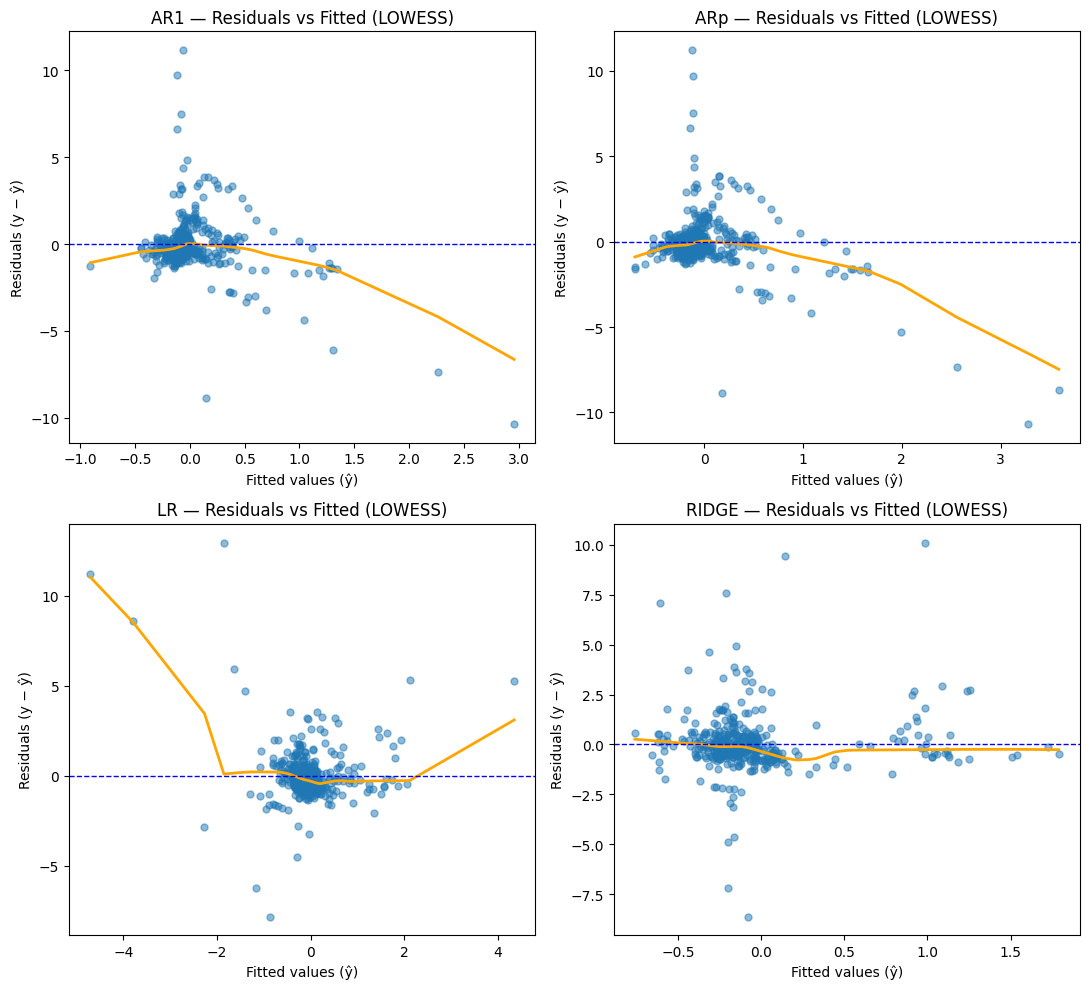

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1) Assurer que wide existe (pipeline officiel)
# =========================================================
# wide doit contenir : date, true, AR1, ARp, LR, RIDGE
if "wide" not in globals():
    raise ValueError("wide n'est pas défini. Recrée-le avec to_wide_from_oos().")

w = wide.copy()
w["date"] = pd.to_datetime(w["date"], errors="coerce")
w = w.dropna(subset=["date", "true"]).sort_values("date")
w = w[w["date"] >= "1990-01-01"]

# =========================================================
# 2) Calcul des résidus
# =========================================================
models = ["AR1", "ARp", "LR", "RIDGE"]

for m in models:
    if m not in w.columns:
        raise ValueError(f"{m} introuvable dans wide.")
    w[f"resid_{m}"] = w["true"] - w[m]

# =========================================================
# 3) Graphique type statsmodels: regplot + LOWESS (4 modèles)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

for ax, m in zip(axes, models):
    sub = w.dropna(subset=[m, f"resid_{m}"])

    sns.regplot(
        x=sub[m],                 # fitted values
        y=sub[f"resid_{m}"],      # residuals
        lowess=True,              # <-- la courbe lissée comme ton exemple
        scatter_kws={"alpha": 0.5, "s": 25},
        line_kws={"color": "orange", "linewidth": 2},
        ax=ax
    )

    ax.axhline(0, color='blue', linestyle='--', linewidth=1)
    ax.set_title(f"{m} — Residuals vs Fitted (LOWESS)")
    ax.set_xlabel("Fitted values (ŷ)")
    ax.set_ylabel("Residuals (y − ŷ)")

plt.tight_layout()
plt.show()

Les résidus ne sont pas totalement aléatoires, ce qui signifie que les modèles ne capturent pas parfaitement la dynamique du chômage.

AR1 et ARp sont précis autour des valeurs moyennes, mais deviennent biaisés pour les valeurs élevées. Ils ont tendance à surestimer le chômage lorsque le niveau prédit est élevé. Cela correspond à la dynamique du chômage : le modèle commence à capter la hausse avec retard et se réajuste trop tard.

La régression linéaire montre une structure d’erreur claire. Elle est trop simple pour ce type de série macroéconomique.

Ridge présente les erreurs les plus stables et mieux centrées autour de zéro. Il offre une meilleure calibration globale, mais des biais persistent pour les valeurs extrêmes.

La présence systématique de ces erreurs confirme que la dynamique du chômage est non linéaire et dépend de régimes économiques.

# Exporter sur MLflow

In [100]:
import os
from pathlib import Path
import pandas as pd
import mlflow

# =========================================================
# 0) Config MLflow
# =========================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
EXPERIMENT_NAME = "H2_advanced_testing"

ART_DIR = Path("evaluation_artifacts_mlflow")
ART_DIR.mkdir(exist_ok=True)

# =========================================================
# 1) Load OOS (AR1 / ARp / LR) + RIDGE (df en mémoire)
# =========================================================
df_ar1 = pd.read_csv("evaluation/oos_predictions_ar1.csv")
df_arp = pd.read_csv("evaluation/oos_predictions_arp_cv.csv")
df_lr  = pd.read_csv("evaluation/oos_predictions_lr.csv")

# RIDGE: df_oos_ridge a date dans l'index
df_ridge = df_oos_ridge.reset_index()  # -> colonne "date" (normalement)
# si la colonne de l'index ne s'appelle pas "date", on la force
if "date" not in df_ridge.columns:
    df_ridge = df_ridge.rename(columns={df_ridge.columns[0]: "date"})

# Harmoniser date (date vs ds)
for d in [df_ar1, df_arp, df_lr]:
    if "date" not in d.columns and "ds" in d.columns:
        d.rename(columns={"ds": "date"}, inplace=True)

# Assurer datetime
for d in [df_ar1, df_arp, df_lr, df_ridge]:
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")

# =========================================================
# 2) Helpers export / logging
# =========================================================
def _safe_to_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=True)
    return str(path)

def _log_df(df: pd.DataFrame, relpath: str):
    p = ART_DIR / relpath
    p.parent.mkdir(parents=True, exist_ok=True)
    _safe_to_csv(df, p)
    mlflow.log_artifact(str(p), artifact_path=str(Path(relpath).parent))

def _ensure_date_index(df: pd.DataFrame) -> pd.DataFrame:
    """Force un index datetime nommé 'date' si la colonne 'date' existe."""
    d = df.copy()
    if "date" in d.columns:
        d = d.dropna(subset=["date"]).set_index("date").sort_index()
    return d

def _parse_mae_cell(x):
    # "0.8788 (0.149)" -> 0.8788
    s = str(x).strip()
    if "(" in s:
        s = s.split("(", 1)[0].strip()
    try:
        return float(s)
    except:
        return None

# =========================================================
# 3) MLflow run: log tables + tests + plots + OOS
# =========================================================
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="eval_tables_tests_AR1_ARp_LR_RIDGE_full_with_OOS") as run:
    # -------------------------
    # Params (traceabilité)
    # -------------------------
    mlflow.log_param("target", "UNRATE")
    mlflow.log_param("horizon_h", 12)
    mlflow.log_param("pi_level", 95)
    mlflow.log_param("segments", "1990-1999|2000-2008|2008-2019|2020-fin")
    mlflow.log_param("dm_lags", 11)
    mlflow.log_param("models", "AR1|ARp|LR|RIDGE")
    mlflow.log_param("coverage_test", "binomial_vs_0.95 + McNemar_paired")
    mlflow.log_param("width_test", "ttest_1samp_vs_0 + paired_ttest_rel")

    # -------------------------
    # ✅ Tables (si déjà calculées dans le notebook)
    # -------------------------
    # attendus: table_pivot, coverage_table, width_table
    if "table_pivot" in globals():
        _log_df(table_pivot, "tables/mae_dm_pivot.csv")

        # headline metrics (Ensemble)
        for m in ["AR1", "ARp", "LR", "RIDGE"]:
            if m in table_pivot.index and "Ensemble" in table_pivot.columns:
                v = _parse_mae_cell(table_pivot.loc[m, "Ensemble"])
                if v is not None:
                    mlflow.log_metric(f"mae_Ensemble_{m}", v)

    if "coverage_table" in globals():
        _log_df(coverage_table, "tables/coverage_pivot.csv")

    if "width_table" in globals():
        _log_df(width_table, "tables/width_pivot.csv")

    # (optionnel) interval score si présent
    if "interval_table_4" in globals():
        _log_df(interval_table_4, "tables/interval_score_pivot.csv")

    # -------------------------
    # ✅ Tests (si déjà calculés dans le notebook)
    # -------------------------
    if "coverage_significance_ridge" in globals():
        _log_df(coverage_significance_ridge, "tests/coverage_binomial_ridge_vs_095.csv")

    if "width_significance_table" in globals():
        _log_df(width_significance_table, "tests/width_ttest_ridge_vs_0.csv")

    if "width_significance_pivot" in globals():
        _log_df(width_significance_pivot, "tests/width_paired_ttest_ridge_vs_models.csv")

    if "coverage_significance_pivot" in globals():
        _log_df(coverage_significance_pivot, "tests/coverage_mcnemar_ridge_vs_models.csv")

    # -------------------------
    # ✅ Plots (si déjà disponibles)
    # -------------------------
    # fig peut être plotly ou matplotlib -> tu peux réutiliser ta fonction _log_figure_any
    if "_log_figure_any" in globals() and "fig" in globals():
        _log_figure_any(fig, ART_DIR / "plots", name="compare_models_plot")

    # log d'un HTML existant si présent
    html_existing = Path("evaluation/plot_compare_AR1_ARp_CV_LR_EXOG.html")
    if html_existing.exists():
        mlflow.log_artifact(str(html_existing), artifact_path="plots")

    # -------------------------
    # ✅ OOS predictions (le point clé)
    # -------------------------
    _log_df(_ensure_date_index(df_ar1),   "oos/oos_predictions_ar1.csv")
    _log_df(_ensure_date_index(df_arp),   "oos/oos_predictions_arp_cv.csv")
    _log_df(_ensure_date_index(df_lr),    "oos/oos_predictions_lr.csv")
    _log_df(_ensure_date_index(df_ridge), "oos/oos_predictions_ridge.csv")

    # (bonus) log wide si tu l'as
    if "wide" in globals():
        # wide peut avoir une colonne "date"
        _log_df(_ensure_date_index(wide), "oos/wide_oos_all_models.csv")

    print("✅ Logged FULL run (tables/tests/plots/OOS) run_id =", run.info.run_id)

✅ Logged FULL run (tables/tests/plots/OOS) run_id = 3368c351f6414b55a58a26b8d77947dd
🏃 View run eval_tables_tests_AR1_ARp_LR_RIDGE_full_with_OOS at: http://127.0.0.1:5000/#/experiments/3/runs/3368c351f6414b55a58a26b8d77947dd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
